In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
import re
import spacy
import seaborn as sns
import matplotlib.pyplot as plt 
import hashlib


from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Téléchargement des données et preprocessing

In [2]:
data = pd.read_csv("data/metadonnees.csv")
data.head()

C:\Users\auran\AppData\Local\Temp\ipykernel_14908\3855839679.py:1: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/metadonnees.csv")


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;As...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,35,entre 30 et 39 ans,greffier de paix,conseiller municipal;conseiller général,non mentionné,non mentionné,combattant,non mentionné,non mentionné,oui
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur;président Coopérative élevage,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,non mentionné,non


In [3]:
data.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='object')

In [4]:
data["date"] = pd.to_datetime(data["date"])

data[["annee","mois","jour"]] = data["date"].apply(
    lambda x: pd.Series([x.year, x.month, x.day])
)
print("Nombre de professions par années :", data["annee"].value_counts().sort_index())

Nombre de professions par années : annee
1958    2774
1959       7
1962    2235
1965       8
1967    2871
1968    2872
1969       8
1973    3843
1974      13
1978    4830
1979       7
1981    3133
1986     740
1988    3551
1989      13
1993    5837
1995      11
1999      14
2002      18
2004      50
2007      13
2009      60
2012      12
2014      97
2019      13
Name: count, dtype: int64


In [5]:
# Export des professions de foi de l'année 1993
zip_path = "C:/Users/auran/OneDrive/Documents/ensae/3A/NLP/legislatives.zip"

docs = []

with zipfile.ZipFile(zip_path) as z:
    for file in z.namelist():
        if file.endswith(".txt"):
            with z.open(file) as f:
                text = f.read().decode("utf-8", errors="ignore")
                docs.append({"file": file, "text": text})

transcriptions = pd.DataFrame(docs)

transcriptions = transcriptions.assign(
    id=transcriptions["file"].str.extract(r'([^/]+)\.txt'),
    annee=transcriptions["file"].str.extract(r'text_files/(\d{4})')
)
transcriptions = transcriptions.drop(columns = ["file"])

transcriptions = transcriptions.merge(data[['id', 'titulaire-soutien']], on='id', how='left')


In [6]:
transcriptions.head()

,text,id,annee,titulaire-soutien
0,Département de Seine-Maritime - 12ème Circonsc...,EL196_L_1993_03_076_12_1_PF_01,1993,non mentionné
1,ELECTIONS LEGISLATIVES DU 21 MARS 1993\nREPUBL...,EL190_L_1993_03_024_02_1_PF_03,1993,non mentionné
2,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,EL190_L_1993_03_017_01_1_PF_07,1993,Parti de la loi naturelle
3,Sciences Po / fonds CEVIPOF\nENTENTE DES ECOLO...,EL192_L_1993_03_050_02_1_PF_03,1993,Verts;Génération écologie
4,Sciences Po / fonds CEVIPOF\nLes Verts Confédé...,EL196_L_1993_03_079_04_1_PF_03,1993,Génération écologie;Verts


In [7]:
len(pd.unique(transcriptions['titulaire-soutien']))

308

On cherche à étudier les différentes méthodes d'adresse des candidats par partis politiques. On ne dispose ici que d'une variable 'titulaire-soutien' qui encode 308 différents courants. On cherche donc à créer une variable plus synthétique regroupant les différents grands partis de l'époque. Le code qui suit peut éventuellement être encore affiné.

In [8]:
# Création d'une autre variable d'affiliation politique plus synthétique

def classifier_parti(etiquette_brute):
    if pd.isna(etiquette_brute) or etiquette_brute == 'nan':
        return np.nan
    
    texte = str(etiquette_brute).lower()
    
    sous_partis = [p.strip() for p in texte.split(';')]
    
    # Drapeaux (Flags) pour détecter les familles présentes
    is_ps = False
    is_udf_rpr = False
    is_centre = False
    is_eco = False
    is_extreme_droite = False
    is_extreme_gauche = False
    is_regionaliste = False
    is_sans_etiquette = False
    
    # Mots-clés par famille
    keywords = {
        'ps': ['parti socialiste', 'ps', 'gauche', 'mouvement des citoyens', 'socialistes', 'socialiste'],

        'rpr' : ['rassemblement pour la république', 'rassemblement pour la republique', 'rpr'],

        'udf' : ['union pour la démocratie française', 'union pour la democratie francaise', 'udf'],
        
        'centre': ['mouvement démocrate', 'modem', 'centriste', 'centre des démocrates sociaux', 
                   'nouveau centre', 'les centristes', 'agir', 'alliance centriste', 
                   'centre', 'mouvement des réformateurs'],
        
        'ecolo': ['vert', 'verts', 'écologie', 'ecolo', 'génération écologie', 'nature et animaux', 
                  'région verte', 'écologiste', 'biosphère', 'generation ecologie', 'écologie les verts',
                  'ecologie les verts', 'ecologie'],
        
        'extreme_droite': ['front national', 'fn', 'mouvement national', 'jeunesse nationaliste', 
                           'alsace d\'abord', 'identitaire', 'patriote', "trop d'immigrés la france aux français"],
        
        'extreme_gauche': ['lutte ouvrière', 'ligue communiste', 'npa', 'nouveau parti anticapitaliste',
                           'parti des travailleurs', 'trotskyste', 'alternative libertaire',
                           'parti communiste français', 'ligue communiste révolutionnaire', 'communistes',
                           'communiste'],
        
        'regionaliste': ['corsica', 'breton', 'occitan', 'alsacien', 'basque', 'euskal', 'unitat catalana',
                         'union démocratique bretonne', 'udb', 'autonomie', 'indépendantiste', 'abertzale',
                         'corse', 'corsa', 'eusko alkartasuna', 'esquerra republicana de catalunya'],
        
        'sans_etiquette': ['sans étiquette', 'divers', 'indépendant', 'apolitique', 'aucun parti', 
                           'non mentionné', 'non inscrit', 'hors des partis', 'société civile', 'libre', 'nan',
                           'sans parti politique', 'aucune formation politique']
    }
    # Analyse de chaque sous-parti
    for parti in sous_partis:
        # Vérification Gauche
        if any(k in parti for k in keywords['ps']):
            is_ps = True
        # Vérification Droite
        if any(k in parti for k in keywords['rpr']) or any(k in parti for k in keywords['udf']):
            is_udf_rpr = True
        # Vérification Centre
        if any(k in parti for k in keywords['centre']):
            is_centre = True
        # Vérification Écologie
        if any(k in parti for k in keywords['ecolo']):
            is_eco = True
        # Vérification Extrême Droite
        if any(k in parti for k in keywords['extreme_droite']):
            is_extreme_droite = True
        # Vérification Extrême Gauche
        if any(k in parti for k in keywords['extreme_gauche']):
            is_extreme_gauche = True
        # Vérification Régionaliste
        if any(k in parti for k in keywords['regionaliste']):
            is_regionaliste = True
        # Vérification Sans étiquette
        if any(k in parti for k in keywords['sans_etiquette']):
            is_sans_etiquette = True

    if is_eco and is_extreme_gauche : 
        return 'Extrême-Gauche'  # 'Ecologiste-Extreme-Gauche

    if is_extreme_droite: return 'Extrême-Droite'
    if is_extreme_gauche: return 'Extrême-Gauche'
    if is_ps: return 'Parti socialiste - Gauche'
    if is_udf_rpr: return 'UDF/RPR'
    if is_centre: return 'Centre'
    if is_eco: return 'Ecologiste'
    if is_regionaliste: return 'Régionaliste'
    if is_sans_etiquette: return 'Sans étiquette / Divers'
    
    # Si rien n'a matché (cas rares ou nouveaux partis)
    return 'Autre / Non classé'

transcriptions['parti_synthetique'] =transcriptions['titulaire-soutien'].apply(classifier_parti)

In [10]:
print("Nombre de candidats par partis : ", transcriptions['parti_synthetique'].value_counts().sort_index())

Nombre de candidats par partis :  parti_synthetique
Autre / Non classé            306
Centre                        121
Ecologiste                   1084
Extrême-Droite                659
Extrême-Gauche                952
Parti socialiste - Gauche     481
Régionaliste                   22
Sans étiquette / Divers      1243
UDF/RPR                       969
Name: count, dtype: int64


On compte beaucoup d'écologistes quand même : est-ce que tel était le cas ou est-ce que j'ai fait quelque chose de biaisé ?

In [11]:
pd.set_option('display.max_colwidth', None)
extrait = transcriptions.sample()

In [12]:
def nettoyage_profession_foi(texte):

    if not isinstance(texte, str):
        return ""
    
    texte = re.sub(r'[\u2600-\u26FF\u2700-\u27BF\u25A0-\u25FF]', ' ', texte)
    #texte = re.sub(r'[A-Z]{4,}\s[A-Z]{4,}', '', texte) 

    # Enlever les 'ELECTIONS LEGISLATIVES'
    texte = re.sub(r'ÉLECTIONS\s[A-Z\s]+-\s[A-Z]+\s\d{4}', '', texte, flags=re.IGNORECASE)

    # Suppression des noms de candidats/suppléants
    texte = re.sub(r'\n?[A-Z][a-z]+\s+[A-Z]{2,}\s+(?:candidat|suppléant)[^\n]*', '', texte) # Suppression des noms de candidats/suppléants
    
    # Suppression de la mention 'Sciences Po/ fonds CEVIPOF'
    texte = re.sub(r'.*?(?:Sciences Po|fonds CEVIPOF|Archives).*?$', '', texte, flags=re.MULTILINE | re.IGNORECASE)
    
    # Nettoyage des espaces et retours à la ligne
    texte = re.sub(r'\n{3,}', '\n\n', texte) 
    texte = re.sub(r'\s+', ' ', texte) 

    # Gestion des apostrophes
    texte = texte.replace('\u2019', "'").replace('\u2018', "'")
    texte = texte.replace('\u2032', "'")
    
    # Suppression des césures
    texte = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', texte)

    # Gestion des listes
    texte = re.sub(r'^\s*[-•·]\s*', '', texte, flags=re.MULTILINE)

    # Gestion des numéros de pages s'il y en a 
    texte = re.sub(r'^\s*\d+\s*$', '', texte, flags=re.MULTILINE)

    return texte.strip()


On ne veut pas nécessairement retirer les stopwords, car l'on veut à terme regarder dans quelle mesure les candidats s'adressent à leurs électeurs, évoquent également d'autres responsables politiques. En particulier, les pronoms personnels ("vous"), les déterminants possessifs ("vos", "nos") sont importants dans ce cas.

In [11]:
# Test 
extrait_nettoye = nettoyage_profession_foi(extrait['text'].iloc[0])
print(extrait_nettoye)

ÉLECTIONS LÉGISLATIVES DE MARS 1993 - 15ème CIRCONSCRIPTION DES BOUCHES-DU-RH FRONT NATIONAL LES FRANÇAIS D'ABORD ! LE PEN avec Jean-Marie VOTEZ Bernard MESLANS Ingénieur E.T.P. 63 ans, marié, 2 enfants. Ancien directeur de la S.A.L.F à Lamanon. Secrétaire F.N de la circonscription. SUPPLÉANTE Jeanine SALVATI-SERRE Agricultrice 46 ans, mariée, 3 enfants Chers compatriotes, Chômage, insécurité, immigration, pauvreté, impôts, "affaires" ... Force est de constater qu'en France aujourd'hui rien ne va plus ! Ce constat dramatique, mais malheureusement bien réel, vous inquiète. Or, il y a des responsables à cet état de fait : ce sont des politiciens de gauche comme de droite qui depuis plus de vingt ans se sont révélés incapables de gouverner correctement notre pays. A juste raison, l'avenir vous apparaît angoissant. Pourtant, en politique, il n'y a pas de fatalité. A nous de prendre notre destin en mains. Si vous voulez que la France retrouve sa force et sa grandeur, si vous voulez que just

In [13]:
# Prend plus de 2 min : il faudrait peut-être mieux faire une boucle for plutôt qu'un apply
transcriptions['texte_nettoye'] = transcriptions['text'].apply(nettoyage_profession_foi)

In [14]:
# Evaluer le nombre de professions de foi similaires (induit un biais dans la suite)
def detecter_textes_similaires(df, col_texte, col_parti, col_id, seuil=0.90):
    """
    Détecte les textes identiques et similaires, par parti politique.
    
    Args:
        df : DataFrame avec les textes
        col_texte : nom de la colonne contenant les textes
        col_parti : nom de la colonne du parti politique
        col_id : nom de la colonne d'identifiant de la profession de foi
        seuil : seuil de similarité (0.90 = 90%)
    
    Returns:
        dict avec les résultats par parti
    """
    resultats = {}
    
    for parti, groupe in df.groupby(col_parti):
        textes = groupe[col_texte].fillna("").tolist()
        ids = groupe[col_id].tolist()
        n = len(textes)
        
        if n < 2:
            continue
        
        # Doublons
        hashes = [hashlib.md5(t.encode()).hexdigest() for t in textes]
        hash_counts = pd.Series(hashes).value_counts()
        nb_doublons_exacts = int((hash_counts > 1).sum())
        
        # Similarité TF-IDF
        vectorizer = TfidfVectorizer(min_df=1)
        tfidf_matrix = vectorizer.fit_transform(textes)
        similarites = cosine_similarity(tfidf_matrix)
        
        # Récupère les paires similaires (triangle supérieur uniquement)
        paires_similaires = []
        for i in range(n):
            for j in range(i + 1, n):
                score = similarites[i, j]
                if score >= seuil:
                    paires_similaires.append({
                        "id_1": ids[i],
                        "id_2" : ids[j],
                        "similarite" : round(score, 3),
                        "texte_1" : textes[i][:80] + "...",  # aperçu
                        "texte_2" : textes[j][:80] + "...",
                    })
        
        resultats[parti] = {
            "nb_textes" : n,
            "nb_doublons_exacts" : nb_doublons_exacts,
            "nb_paires_similaires": len(paires_similaires)
        }
    
    return resultats

In [15]:
def resumer_resultats(resultats):
    """Produit un DataFrame de synthèse par parti."""
    rows = []
    for parti, res in resultats.items():
        rows.append({
            "parti"               : parti,
            "nb_textes"           : res["nb_textes"],
            "nb_doublons_exacts"  : res["nb_doublons_exacts"],
            "nb_paires_similaires": res["nb_paires_similaires"],
            "taux_similarite"     : round(res["nb_paires_similaires"] / (res["nb_textes"]**2-res["nb_textes"]), 2)
        })
    return pd.DataFrame(rows).sort_values("nb_paires_similaires", ascending=False)

In [16]:
resultats_similarites = detecter_textes_similaires(transcriptions, "texte_nettoye", "parti_synthetique", "id", 0.90)
df_similarites = resumer_resultats(resultats_similarites)
df_similarites

,parti,nb_textes,nb_doublons_exacts,nb_paires_similaires,taux_similarite
2,Ecologiste,1084,34,100900,0.09
4,Extrême-Gauche,952,16,28076,0.03
0,Autre / Non classé,306,1,4349,0.05
3,Extrême-Droite,659,0,1163,0.00
1,Centre,121,0,106,0.01
7,Sans étiquette / Divers,1243,0,48,0.00
8,UDF/RPR,969,1,13,0.00
5,Parti socialiste - Gauche,481,0,10,0.00
6,Régionaliste,22,0,6,0.01


Il sera peut être utile d'utiliser ces résultats comme pondération si l'on considère des variables de comptage plus tard (en valeur absolue et non en proportions) par parti.

Peut être qu'il faut aussi repondérer d'une certaine manière les résultats en proportion ? Si l'on recense un grand nombre de textes similaires les probabilités d'avoir un résultat plutôt qu'un autre sont biaisées...

## Analyse des pronoms

In [ ]:
# Tokenization
nlp = spacy.load("fr_core_news_lg")  # Au préalable, télécharger : python -m spacy download fr_core_news_sm

def tokenizer_et_pos(texte_propre):
    """Prend un texte déjà nettoyé et en minuscules, retourne tokens et POS"""
    doc = nlp(texte_propre)
    return [(token.text, token.pos_) for token in doc if not token.is_space]

# Petit test
token_extrait = tokenizer_et_pos(extrait_nettoye)

print(token_extrait[:15])

In [18]:
# Prends plus de 4 minutes à s'exécuter
textes = transcriptions['texte_nettoye'].tolist()
resultats = []

for doc in nlp.pipe(textes, batch_size=50, disable=["tagger", "parser", "ner"]):

    comptes = {'je': 0, 'nous': 0, 'vous': 0, 'on': 0, 'total_pronoms': 0}
    total_mots = 0
    
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        total_mots += 1
        
        if token.pos_ == "PRON":

            lemme = token.text.lower()
            
            # Mapping intelligent basé sur le lemme
            if lemme in ['je', 'moi', 'me', "m'", "mes", "ma"]:
                comptes['je'] += 1
            elif lemme in ['nous', 'notre', 'nos', "nôtres"]: 
                comptes['nous'] += 1
            elif lemme in ['vous', 'votre', 'vos', "vôtres"]:
                comptes['vous'] += 1
            elif lemme == 'on':
                comptes['on'] += 1
            
            comptes['total_pronoms'] += 1

    ratios = {}
    for key in ['je', 'nous', 'vous', 'on']:
        ratios[f'{key}_p1000'] = (comptes[key] / total_mots * 1000) if total_mots > 0 else 0
        
    total_je_nous = comptes['je'] + comptes['nous']
    ratios['ratio_je_nous'] = comptes['je'] / total_je_nous if total_je_nous > 0 else 0

    total_je_vous = comptes['je'] + comptes['vous']
    ratios['ratio_je_vous'] = comptes['je'] / total_je_vous if total_je_vous > 0 else 0
    
    resultats.append(ratios)


In [16]:
pronoms_stats = pd.DataFrame(resultats, index=transcriptions['texte_nettoye'].index)
transcriptions_analysis = pd.concat([transcriptions, pronoms_stats], axis=1)
transcriptions_analysis = transcriptions_analysis.drop(columns = ['text', 'annee', 'titulaire-soutien', 'texte_nettoye'])

In [17]:
cols_scores = ['je_p1000', 'nous_p1000', 'vous_p1000', 'on_p1000', 'ratio_je_nous', 'ratio_je_vous']
agg_stats = transcriptions_analysis.groupby('parti_synthetique')[cols_scores].agg(['mean', 'std']).reset_index()
agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

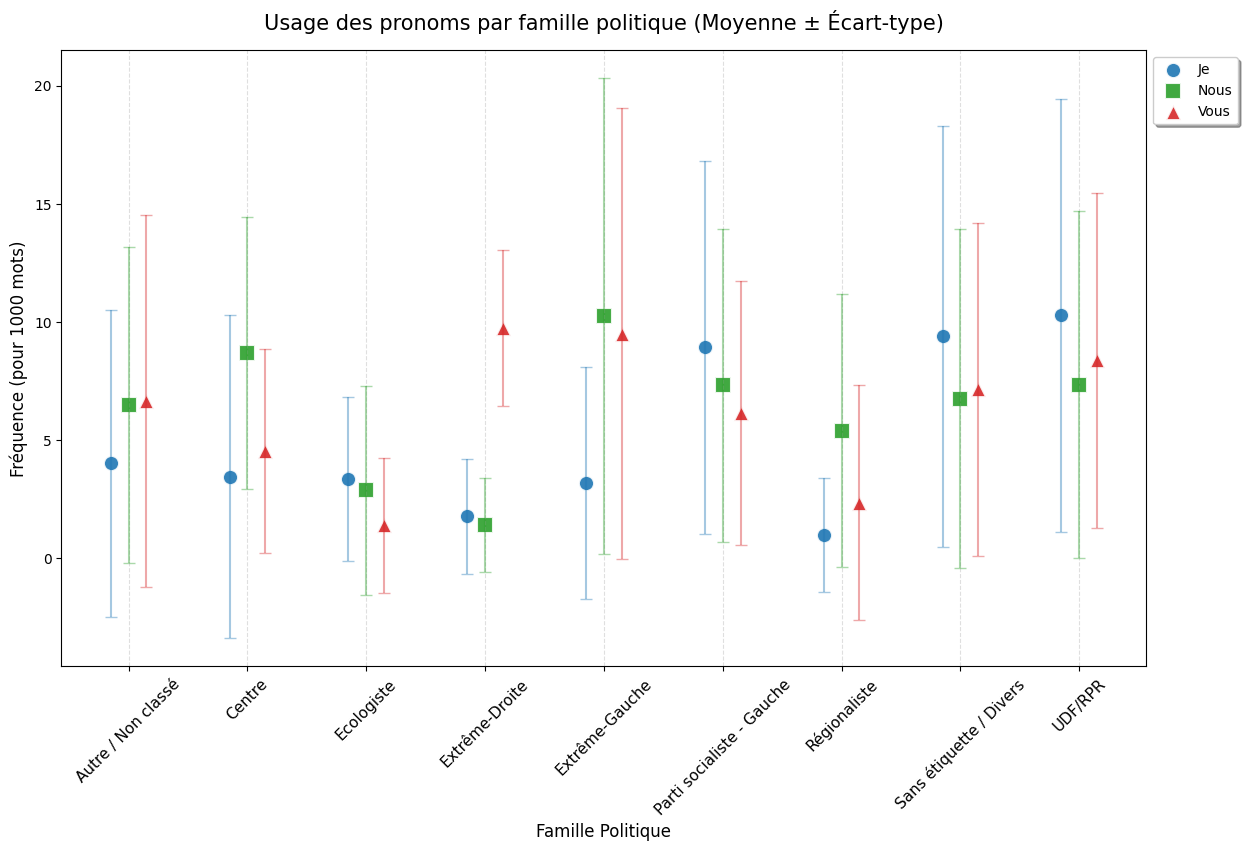

In [18]:
df = agg_stats.copy()
partis = df['parti_synthetique']
y_pos = np.arange(len(partis))  

plt.figure(figsize=(14, 8))

offset = 0.15 

plt.scatter(
    y_pos - offset, 
    df['je_p1000_mean'], 
    s=120,                # Taille des points
    c='#1f77b4',          # Couleur Bleu
    marker='o',           # Cercle
    label='Je', 
    edgecolors='white',   # Bordure blanche pour détacher du fond
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Je
plt.errorbar(y_pos - offset, df['je_p1000_mean'], yerr=df['je_p1000_std'], 
             fmt='none', ecolor='#1f77b4', alpha=0.4, capsize=4)

plt.scatter(
    y_pos, 
    df['nous_p1000_mean'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           # Carré
    label='Nous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Nous
plt.errorbar(y_pos, df['nous_p1000_mean'], yerr=df['nous_p1000_std'], 
             fmt='none', ecolor='#2ca02c', alpha=0.4, capsize=4)


plt.scatter(
    y_pos + offset, 
    df['vous_p1000_mean'], 
    s=120, 
    c='#d62728', 
    marker='^',           # Triangle
    label='Vous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Vous
plt.errorbar(y_pos + offset, df['vous_p1000_mean'], yerr=df['vous_p1000_std'], 
             fmt='none', ecolor='#d62728', alpha=0.4, capsize=4)

plt.title("Usage des pronoms par famille politique (Moyenne ± Écart-type)", fontsize=15, pad=15)
plt.xlabel("Famille Politique", fontsize=12)
plt.ylabel("Fréquence (pour 1000 mots)", fontsize=12)

# Remplacement des ticks numériques par les noms des partis
plt.xticks(y_pos, partis, fontsize=11, rotation = 45)

# Grille horizontale uniquement pour aider à lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Légende flottante pour ne pas gêner les points
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)


plt.show()

<b>Faire de meilleures stats desc !!! </b> 

Idées : étudier les verbes (actions/états) employés dans le discours.
Quelles fonctions ont les 'nous', les 'vous' dans la phrase ? (sujet, COD, autre)

### Identification de la fonction dans la phrase 

Les quelques cellules ci-dessous tentent d'identifier la fonction des pronoms 'je', 'nous', 'vous' lorsqu'ils sont utilisés (sujet VS objet), ainsi que le type de verbe qui les succède ou précède (action VS état).

In [20]:
# Verbes statifs
VERBES_ETAT = {'être', 'paraître', 'sembler', 'demeurer', 'rester', 'devenir', 'voir', 'vivre'
               'devoir', 'pouvoir', 'vouloir', 'falloir', 'savoir', 'croire', 'penser', 'appeler'}

VERBES_MODAUX = {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire', 'laisser', 'sembler', 'paraître'}


In [35]:
# Prend environ 3-4 min 
textes = transcriptions['texte_nettoye'].tolist()

results = []

for doc in nlp.pipe(textes, batch_size=50, disable=["ner"]):
    
    stats = {'je': defaultdict(int), 'nous': defaultdict(int), 'vous': defaultdict(int)}
    mapping_pronom = {
        'je': ['je', "j'", 'moi', 'me', "m'"],
        'nous': ['nous'],
        'vous': ['vous']
    }

    for token in doc:
        if token.is_space or token.is_punct: 
            continue
        
        pronom_type = None
        if token.pos_ == "PRON":
            for p_type, formes in mapping_pronom.items():
                if token.text.lower() in formes or token.lemma_.lower() in formes:
                    pronom_type = p_type
                    break
        
        if pronom_type:
            verbe = None
            fonction = None
            
            if token.dep_ in ("nsubj", "nsubjpass"):
                fonction = "sujet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head
            elif token.dep_ in ("dobj", "obj", "iobj", "obl"):
                fonction = "objet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head

            lemme_tete = verbe_cible.lemma_.lower() # Ex type : Nous devons agir : on veut identifier agir et non devoir
            if lemme_tete in VERBES_MODAUX: # {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire'}
                for child in verbe_cible.children:
                    if child.pos_ == "VERB":
                        verbe = child # On remplace le modal par le verbe enfant
                        break
            else :
                verbe = verbe_cible
                
            if verbe:
                v_lem = verbe.lemma_.lower()
                type_v = "etat" if v_lem in VERBES_ETAT else "action"
                stats[pronom_type][f"{fonction}_{type_v}"] += 1
                stats[pronom_type][f"{fonction}"] +=1
                stats[pronom_type][f"{type_v}"] +=1

    row = {}
    for p in ['je', 'nous', 'vous']:
        for k, v in stats[p].items():
            row[f"{p}_{k}"] = v
    
    for p in ['je', 'nous', 'vous']:
        for f in ['sujet', 'objet']:
            for t in ['action', 'etat']:
                key = f"{p}_{f}_{t}"
                if key not in row: 
                    row[key] = 0
                
    results.append(row)

df_structure = pd.DataFrame(results)

# Concaténation avec les infos originales
transcriptions_structure_test = pd.concat([transcriptions[['id', 'parti_synthetique']], df_structure], axis=1)

In [70]:
df_structure.shape


(5936, 33)

In [36]:
transcriptions_structure_test.columns

Index(['id', 'parti_synthetique', 'je_objet_action', 'je_objet', 'je_action',
       'je_sujet_action', 'je_sujet', 'je_None_action', 'je_None',
       'nous_sujet_action', 'nous_sujet', 'nous_action', 'nous_None_action',
       'nous_None', 'vous_objet_action', 'vous_objet', 'vous_action',
       'vous_sujet_action', 'vous_sujet', 'vous_None_action', 'vous_None',
       'je_sujet_etat', 'je_objet_etat', 'nous_sujet_etat',
       'nous_objet_action', 'nous_objet_etat', 'vous_sujet_etat',
       'vous_objet_etat', 'je_etat', 'vous_None_etat', 'vous_etat',
       'nous_etat', 'nous_objet', 'nous_None_etat', 'je_None_etat'],
      dtype='object')

In [37]:
cols_scores = ['je_objet_action', 'je_objet', 'je_action',
       'je_sujet_action', 'je_sujet', 'je_None_action', 'je_None',
       'nous_sujet_action', 'nous_sujet', 'nous_action', 'nous_None_action',
       'nous_None', 'vous_objet_action', 'vous_objet', 'vous_action',
       'vous_sujet_action', 'vous_sujet', 'vous_None_action', 'vous_None',
       'je_sujet_etat', 'je_objet_etat', 'nous_sujet_etat',
       'nous_objet_action', 'nous_objet_etat', 'vous_sujet_etat',
       'vous_objet_etat', 'je_etat', 'vous_None_etat', 'vous_etat',
       'nous_etat', 'nous_objet', 'nous_None_etat', 'je_None_etat']  # A CHANGER

agg_stats = transcriptions_structure_test.groupby('parti_synthetique')[cols_scores].agg(['sum']).reset_index()
agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

In [38]:
agg_stats

,parti_synthetique,je_objet_action_sum,je_objet_sum,je_action_sum,je_sujet_action_sum,je_sujet_sum,je_None_action_sum,je_None_sum,nous_sujet_action_sum,nous_sujet_sum,...,nous_objet_etat_sum,vous_sujet_etat_sum,vous_objet_etat_sum,je_etat_sum,vous_None_etat_sum,vous_etat_sum,nous_etat_sum,nous_objet_sum,nous_None_etat_sum,je_None_etat_sum
0,Autre / Non classé,130,131.0,759.0,482,544.0,147.0,156.0,959,1053.0,...,16,34,3,72.0,31.0,68.0,123.0,138.0,13.0,9.0
1,Centre,17,17.0,290.0,200,219.0,73.0,77.0,166,203.0,...,10,5,0,23.0,24.0,29.0,59.0,29.0,12.0,4.0
2,Ecologiste,73,75.0,1745.0,1393,1496.0,279.0,292.0,1297,1414.0,...,67,48,8,118.0,20.0,76.0,207.0,285.0,23.0,13.0
3,Extrême-Droite,32,32.0,933.0,788,851.0,113.0,118.0,149,170.0,...,0,142,6,68.0,47.0,195.0,24.0,512.0,3.0,5.0
4,Extrême-Gauche,148,150.0,2159.0,1482,1816.0,529.0,591.0,5022,5889.0,...,482,334,53,398.0,341.0,728.0,1717.0,2116.0,368.0,62.0
5,Parti socialiste - Gauche,231,233.0,3116.0,2214,2497.0,671.0,707.0,1332,1543.0,...,65,79,21,321.0,67.0,167.0,321.0,277.0,45.0,36.0
6,Régionaliste,2,2.0,13.0,8,11.0,3.0,3.0,64,69.0,...,1,9,0,3.0,0.0,9.0,6.0,14.0,0.0,0.0
7,Sans étiquette / Divers,737,744.0,7012.0,4855,5500.0,1420.0,1512.0,2637,2986.0,...,98,221,54,744.0,129.0,404.0,531.0,703.0,84.0,92.0
8,UDF/RPR,605,609.0,5156.0,3391,3792.0,1160.0,1210.0,2106,2280.0,...,86,134,32,455.0,85.0,251.0,307.0,503.0,47.0,50.0


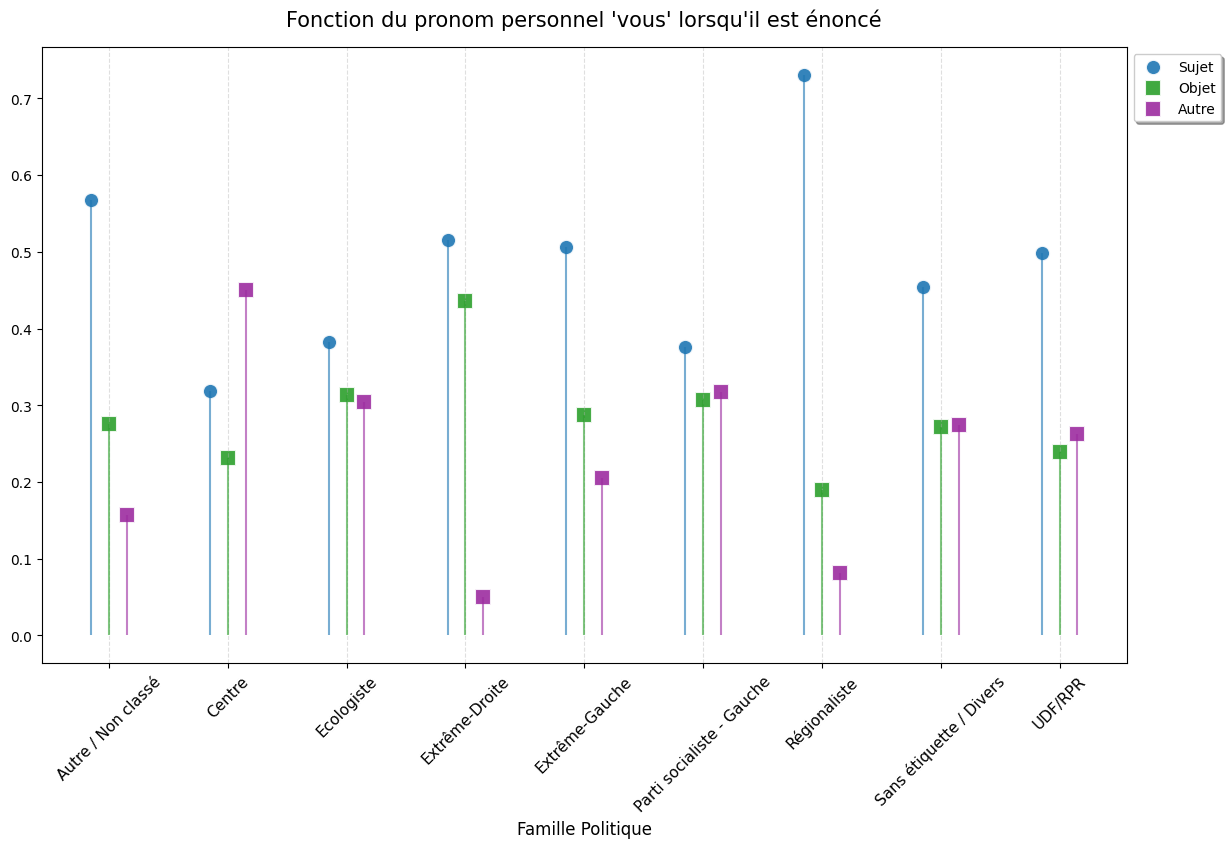

In [39]:
# Vous sujet VS objet 
df = agg_stats[['parti_synthetique', 'vous_sujet_sum', 'vous_objet_sum', 'vous_None_sum']].copy()
df['prop_vous_sujet'] = df['vous_sujet_sum']/(df['vous_sujet_sum']+df['vous_objet_sum'] + df['vous_None_sum'])
df['prop_vous_objet'] = df['vous_objet_sum']/(df['vous_sujet_sum']+df['vous_objet_sum'] + df['vous_None_sum'])
df['prop_vous_None'] = 1-df['prop_vous_objet']-df['prop_vous_sujet']

partis = df['parti_synthetique']
y_pos = np.arange(len(partis))  

plt.figure(figsize=(14, 8))

offset = 0.15 

# --- Sujet ---
plt.vlines(y_pos - offset, 0, df['prop_vous_sujet'],
           colors='#1f77b4', linewidth=1.5, alpha=0.6)
plt.scatter(
    y_pos - offset, 
    df['prop_vous_sujet'], 
    s=120,                # Taille des points
    c='#1f77b4',          # Couleur Bleu
    marker='o',           # Cercle
    label='Sujet', 
    edgecolors='white',   # Bordure blanche pour détacher du fond
    linewidth=1.5,
    alpha=0.9
)

# --- Objet ---
plt.vlines(y_pos, 0, df['prop_vous_objet'],
           colors='#2ca02c', linewidth=1.5, alpha=0.6)
plt.scatter(
    y_pos, 
    df['prop_vous_objet'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           # Carré
    label='Objet', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)

# --- Autre ---
plt.vlines(y_pos + offset, 0, df['prop_vous_None'],
           colors='#9c2ca0', linewidth=1.5, alpha=0.6)
plt.scatter(
    y_pos+offset, 
    df['prop_vous_None'], 
    s=120, 
    c="#9c2ca0", 
    marker='s',           # Carré
    label='Autre', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)

plt.title("Fonction du pronom personnel 'vous' lorsqu'il est énoncé", fontsize=15, pad=15)
plt.xlabel("Famille Politique", fontsize=12)

# Remplacement des ticks numériques par les noms des partis
plt.xticks(y_pos, partis, fontsize=11, rotation = 45)

# Grille horizontale uniquement pour aider à lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Légende flottante pour ne pas gêner les points
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)


plt.show()

### Etude du pronom '*vous*' seulement

In [19]:
def _cherche_relation_je_nous(vous_token, pronoms_je_nous: set) -> str | None:
    """
    Cherche si je/nous est relié à 'vous' dans la même phrase.
    
    Logique :
    - Si 'vous' est COD/COI → cherche le sujet du même verbe
    - Si 'vous' est sujet   → cherche un autre sujet coordonné (nous et vous)
    """
    verbe = vous_token.head
    
    # Parcourt les enfants du même verbe
    for sibling in verbe.children:
        if sibling.text.lower() in pronoms_je_nous:
            if sibling.dep_ in ("nsubj", "nsubj:pass"):
                return sibling.text.lower() 
    
    # Cherche aussi dans les tokens de la phrase entière
    for token in vous_token.sent:
        if token.text.lower() in pronoms_je_nous:
            if token.head == verbe:
                return token.text.lower() 
    return None

In [20]:
def analyser_vous(textes: list[str], textes_id, parti_pol) -> list[dict]:
    """
    Pour chaque occurrence de 'vous' dans les textes,
    retourne sa fonction syntaxique et si elle est reliée à je/nous.
    """
    resultats = []
    
    dep_to_fonction = {
        "nsubj" : "sujet",
        "nsubj:pass" : "sujet",
        "expl:subj" : "sujet",
        "obj" : "COD",
        "expl:comp" : "COD",
        "iobj" : "COI",
        "obl" : "COI",
        "obl:arg" : "COI",
        "obl:mod" : "COI",
        "obl:agent" : "COI",
        "amod" : "COI",
        "advmod" : "COI",
        "nmod" : "complément du nom",
        "appos" : "apposition",     # "vous qui..."
        "conj" : "coordination", # "vous et eux"
        "dep" : "autre/indéterminé",
    }
    
    pronoms_je_nous = {"je", "j'", "nous", "j", "me", "moi", "m", "m'"}

    pipe = nlp.pipe(textes, batch_size=64, disable=["ner"])
    
    for i, doc in enumerate(pipe):

        idx_original = textes_id[i]
        parti_pol_original = parti_pol[i]
        
        for sent in doc.sents:
            for token in sent :
                if token.text.lower() != "vous":
                    continue

                fonction = dep_to_fonction.get(token.dep_, "autre/indéterminé")
                relie_a = _cherche_relation_je_nous(token, pronoms_je_nous)
                
                resultats.append({
                    "texte_id"    : idx_original,
                    "phrase"      : sent.text.strip(),
                    "vous_index"  : token.i,
                    "verbe"       : token.head.text if token.head != token else None,  # Le mot dont vous dépend
                    "dep_raw"     : token.dep_,  # Fonction brute de spacy 
                    "fonction"    : fonction,  # Fonction de vous dans la phrase telle qu'on l'a encodée
                    "relie_je_nous": relie_a,    # None si pas de relation
                    "parti_politique" : parti_pol_original
                })
    
    return resultats

In [21]:
resultats_vous = analyser_vous(textes, transcriptions["id"], transcriptions["parti_synthetique"])

df_vous = pd.DataFrame(resultats_vous)

print("Nombre de fonctions : ", df_vous['fonction'].value_counts())
print("")
print("Co-occurences de je/nous reliés à vous :", df_vous['relie_je_nous'].value_counts(dropna=False))

Nombre de fonctions :  fonction
sujet                12757
COI                   8329
COD                   1965
autre/indéterminé     1114
complément du nom      911
coordination           162
apposition              19
Name: count, dtype: int64

Co-occurences de je/nous reliés à vous : relie_je_nous
None    20239
je       2843
nous     1133
m'        436
moi       221
me        217
j'        164
m           2
j           2
Name: count, dtype: int64


In [22]:
agg_df_vous = df_vous.groupby(['parti_politique', 'fonction']).size().unstack(fill_value=0).reset_index()
agg_df_vous['non_sujet'] = agg_df_vous["COD"]+agg_df_vous["COI"]+agg_df_vous["apposition"]+agg_df_vous["autre/indéterminé"]+agg_df_vous["complément du nom"]+agg_df_vous["coordination"]
agg_df_vous["prop_sujet"] = agg_df_vous["sujet"]/(agg_df_vous["sujet"]+agg_df_vous["non_sujet"])
agg_df_vous["prop_non_sujet"] = 1-agg_df_vous["prop_sujet"]
agg_df_vous
#agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

fonction,parti_politique,COD,COI,apposition,autre/indéterminé,complément du nom,coordination,sujet,non_sujet,prop_sujet,prop_non_sujet
0,Autre / Non classé,70,356,1,22,84,3,715,536,0.571543,0.428457
1,Centre,13,88,0,69,18,1,92,189,0.327402,0.672598
2,Ecologiste,74,391,1,54,32,15,364,567,0.390977,0.609023
3,Extrême-Droite,49,2100,3,121,50,5,3262,2328,0.583542,0.416458
4,Extrême-Gauche,810,1929,4,303,252,37,3440,3335,0.507749,0.492251
5,Parti socialiste - Gauche,152,795,1,74,70,9,786,1101,0.416534,0.583466
6,Régionaliste,2,7,0,1,0,0,27,10,0.729730,0.270270
7,Sans étiquette / Divers,435,1498,7,287,237,54,2131,2518,0.458378,0.541622
8,UDF/RPR,352,1134,2,179,168,38,1906,1873,0.504366,0.495634


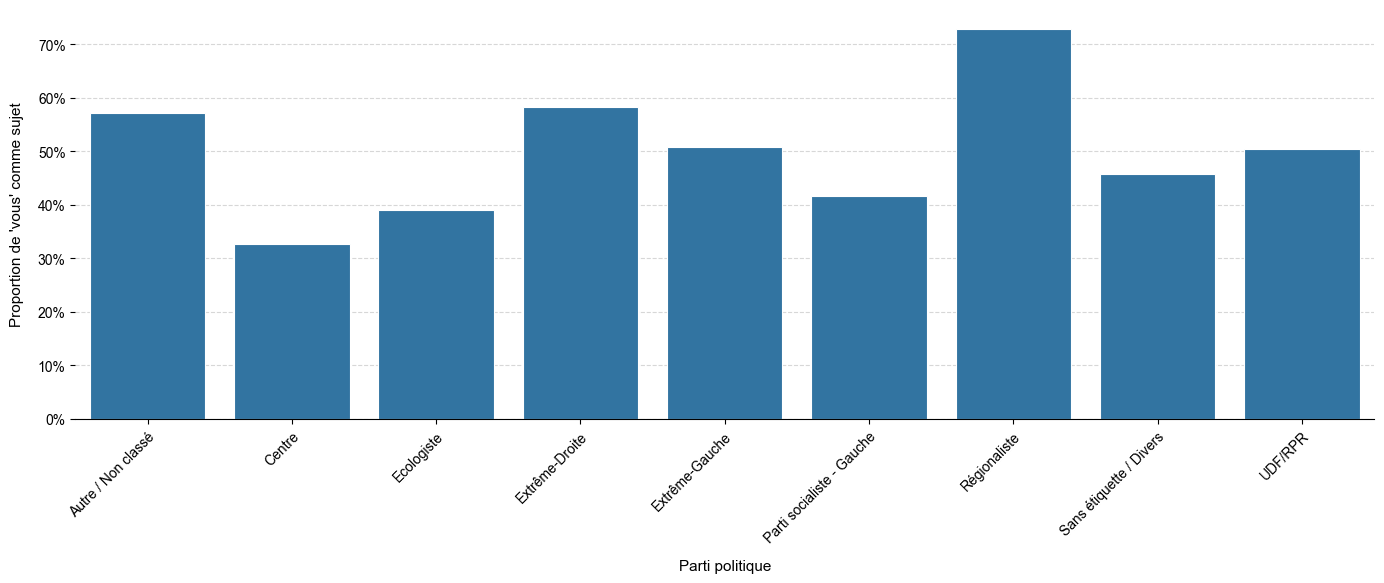

In [23]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(agg_df_vous))


bars = sns.barplot(
    data    = agg_df_vous,
    x       = "parti_politique",
    y       = "prop_sujet",
    edgecolor = "white",
    linewidth = 0.8,
    ax      = ax
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Proportion de 'vous' comme sujet", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(agg_df_vous)))
ax.set_xticklabels(
    agg_df_vous["parti_politique"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

In [38]:
agg_df_je_vous = df_vous.groupby(['parti_politique', 'relie_je_nous'], dropna=False).size().unstack(fill_value=0).reset_index()
agg_df_je_vous["je_tot"] = agg_df_je_vous["j"]+agg_df_je_vous["j'"]+agg_df_je_vous["je"]+agg_df_je_vous["m"]+agg_df_je_vous["m'"]+agg_df_je_vous["me"]+agg_df_je_vous["moi"]+agg_df_je_vous["nous"]
agg_df_je_vous['total'] = agg_df_je_vous.drop(columns=['parti_politique', 'je_tot']).sum(axis=1)
agg_df_je_vous["je_prop"] = agg_df_je_vous["je_tot"]/agg_df_je_vous["total"]
agg_df_je_vous

relie_je_nous,parti_politique,j,j',je,m,m',me,moi,nous,NaN,je_tot,total,je_prop
0,Autre / Non classé,0,0,123,0,12,6,12,61,1037,214,1251,0.171063
1,Centre,0,2,27,0,2,1,1,33,215,66,281,0.234875
2,Ecologiste,0,5,93,0,7,6,2,98,720,211,931,0.226638
3,Extrême-Droite,0,1,554,0,5,2,1,4,5023,567,5590,0.101431
4,Extrême-Gauche,1,21,329,0,33,40,146,441,5764,1011,6775,0.149225
5,Parti socialiste - Gauche,0,49,420,1,44,22,9,88,1254,633,1887,0.335453
6,Régionaliste,0,0,2,0,0,0,0,0,35,2,37,0.054054
7,Sans étiquette / Divers,0,44,718,0,153,84,29,197,3424,1225,4649,0.263498
8,UDF/RPR,1,42,572,1,179,55,20,206,2703,1076,3779,0.284731
9,NaN,0,0,5,0,1,1,1,5,64,13,77,0.168831


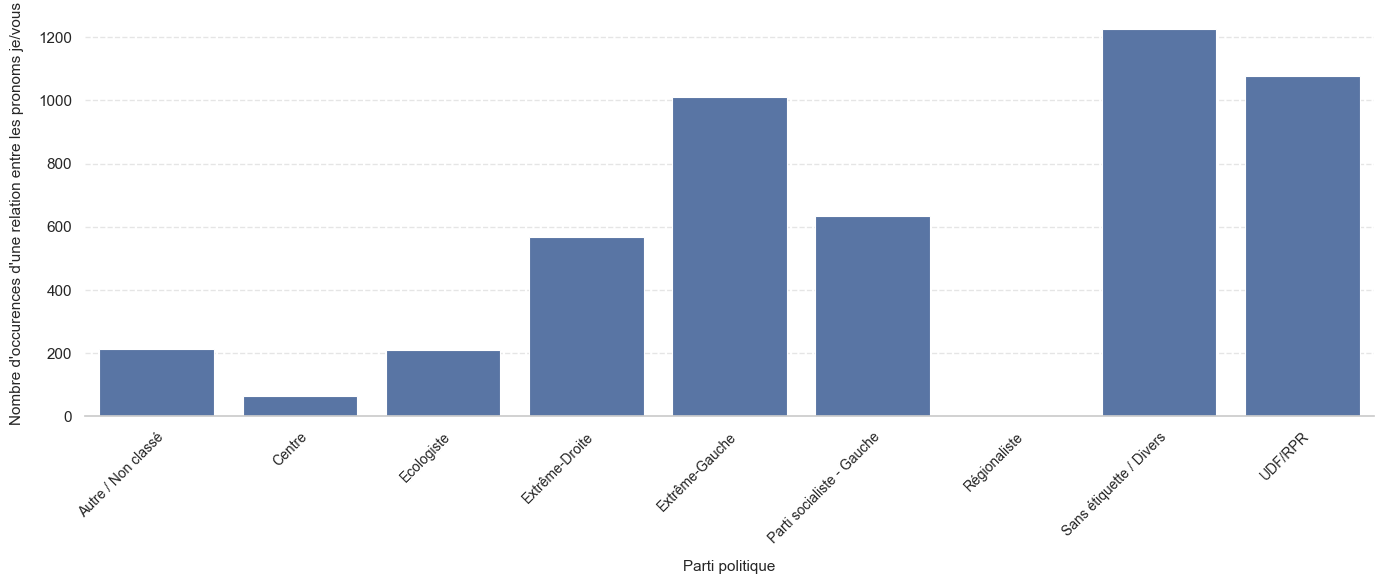

In [40]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(agg_df_vous))


bars = sns.barplot(
    data    = agg_df_je_vous,
    x       = "parti_politique",
    y       = "je_tot",
    edgecolor = "white",
    linewidth = 0.8,
    ax      = ax
)

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Nombre d'occurences d'une relation entre les pronoms je/vous", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(agg_df_vous)))
ax.set_xticklabels(
    agg_df_vous["parti_politique"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

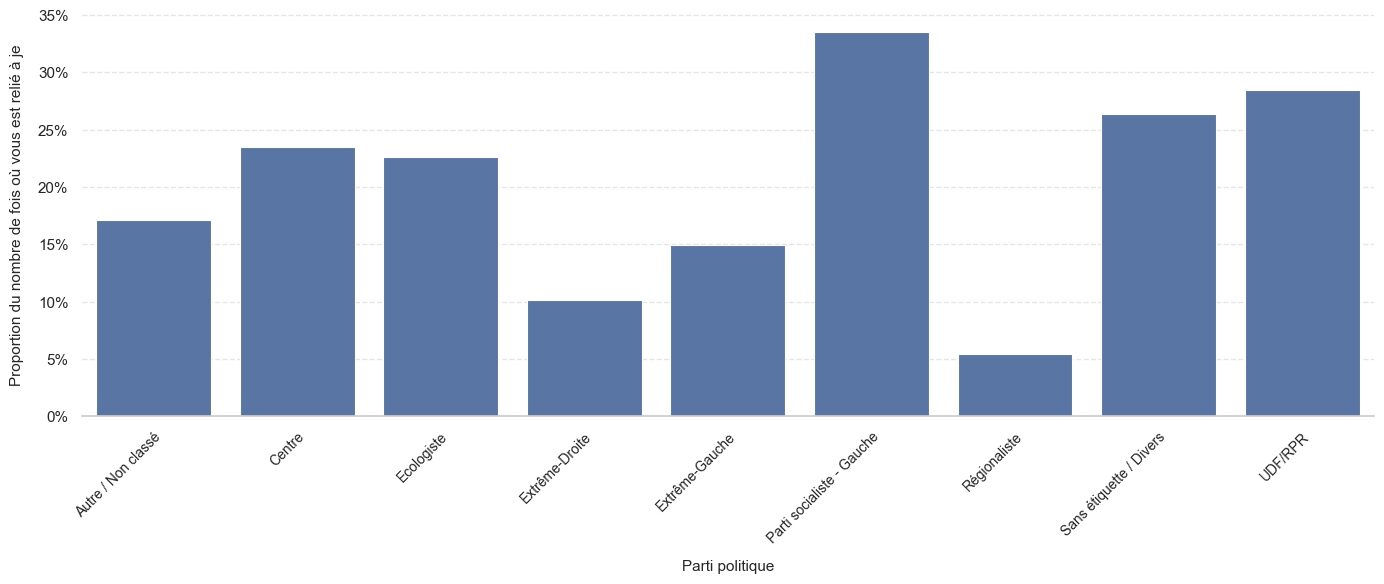

In [41]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(agg_df_vous))


bars = sns.barplot(
    data    = agg_df_je_vous,
    x       = "parti_politique",
    y       = "je_prop",
    edgecolor = "white",
    linewidth = 0.8,
    ax      = ax
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Proportion du nombre de fois où vous est relié à je", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(agg_df_vous)))
ax.set_xticklabels(
    agg_df_vous["parti_politique"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

Statistiques descriptives (<b> A FAIRE ! </b>)

### **IDEE** : FAIRE PAREIL AVEC 'JE' déjà en discriminant si le verbe qui suit est 'ROOT' ou 'AUX'

### Reprise de ce qu'il se passait avant (j'ai coupé au milieu)

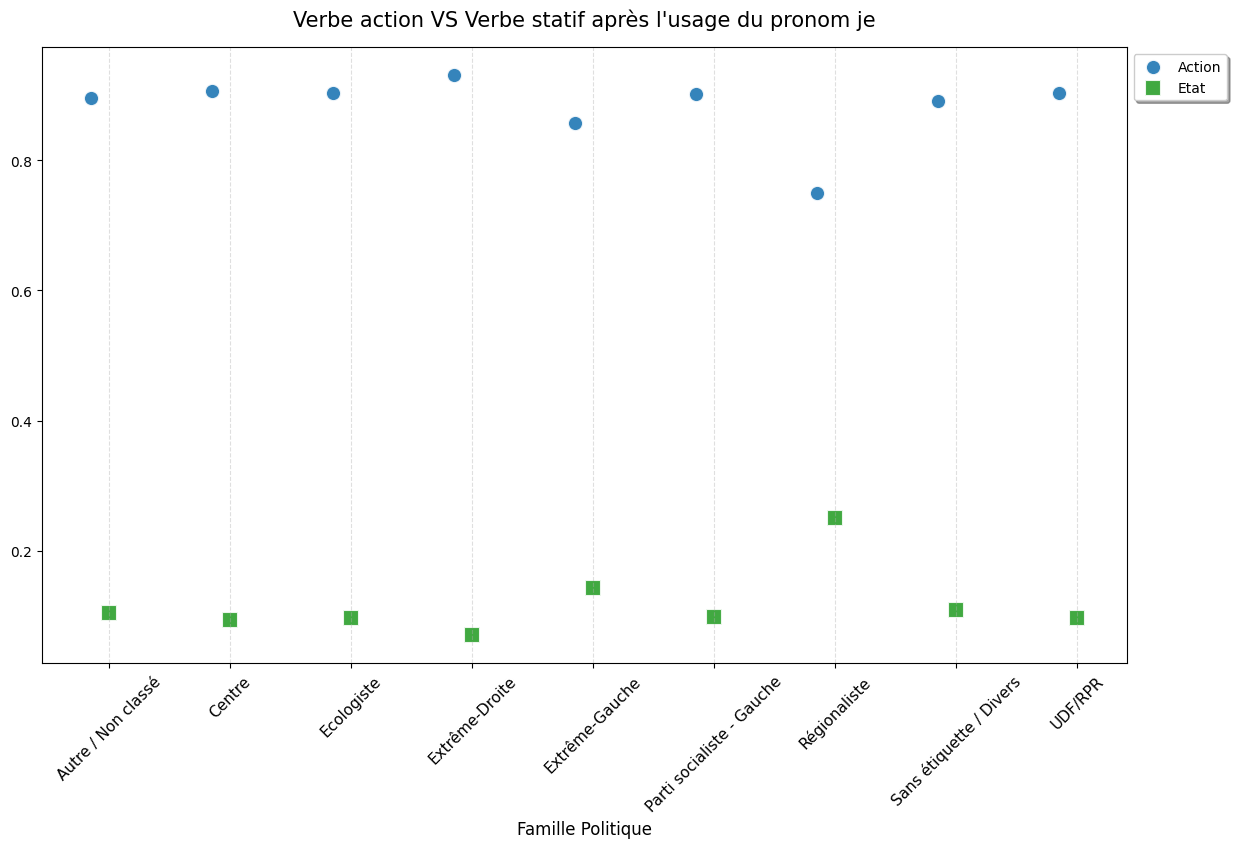

In [25]:
# Je action VS je etat

df = agg_stats[['parti_synthetique', 'je_action_sum', 'je_etat_sum']].copy()
df['prop_je_action'] = df['je_action_sum']/(df['je_action_sum']+df['je_etat_sum'])
df['prop_je_etat'] = 1- df['prop_je_action']
partis = df['parti_synthetique']
y_pos = np.arange(len(partis))  

plt.figure(figsize=(14, 8))

offset = 0.15 

plt.scatter(
    y_pos - offset, 
    df['prop_je_action'], 
    s=120,                # Taille des points
    c='#1f77b4',          # Couleur Bleu
    marker='o',           # Cercle
    label='Action', 
    edgecolors='white',   # Bordure blanche pour détacher du fond
    linewidth=1.5,
    alpha=0.9
)

plt.scatter(
    y_pos, 
    df['prop_je_etat'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           # Carré
    label='Etat', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)

plt.title("Verbe action VS Verbe statif après l'usage du pronom je", fontsize=15, pad=15)
plt.xlabel("Famille Politique", fontsize=12)

# Remplacement des ticks numériques par les noms des partis
plt.xticks(y_pos, partis, fontsize=11, rotation = 45)

# Grille horizontale uniquement pour aider à lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Légende flottante pour ne pas gêner les points
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)


plt.show()

C'est pas hyper instructif. Il faut regarder aussi la place dans la phrase. 

### Echantillonnage de phrases à annoter

In [27]:
PRONOMS_CIBLES = {'je', 'nous', 'vous', "j'", "m'"}

def segmenter_et_extraire_features(texte_long):
    """
    Découpe un texte en phrases et identifie celles dans lesquelles apparaît un des pronoms cibles.
    Retourne une liste de dictionnaires : {'texte': phrase, 'doc_id': id}
    """
    doc = nlp(texte_long)
    phrases_interessantes = []
    
    for sent in doc.sents:
            
        sent_text = sent.text.strip()
        has_pronom = False
        pronoms_in_sent = []
        
        for token in sent:
            t_lower = token.text.lower()
            l_lower = token.lemma_.lower()
            
            if t_lower in PRONOMS_CIBLES and token.pos_ == "PRON":
                has_pronom = True
                pronoms_in_sent.append(t_lower)
            
            if has_pronom : 
                phrases_interessantes.append({
                    "texte": sent_text,
                    "pronoms": pronoms_in_sent
                })
                
    return phrases_interessantes


In [28]:
len(transcriptions['texte_nettoye'])

5936

In [29]:
sample_texts = transcriptions[['texte_nettoye', 'id']].sample(n = 1000)

print("Segmentation des textes en phrases...")
toutes_les_phrases = []

for idx, texte in sample_texts['texte_nettoye'].items():
    if isinstance(texte, str) and len(texte) > 10:
        phrases = segmenter_et_extraire_features(texte)
        id_text = sample_texts['id'][idx]
        for p in phrases:
            p['doc_id'] = id_text
        toutes_les_phrases.extend(phrases)

print(f"Total de phrases candidates extraites : {len(toutes_les_phrases)}")


Segmentation des textes en phrases...
Total de phrases candidates extraites : 151893


In [30]:
echantillon_final = []

list_je = [p for p in toutes_les_phrases if ('je' in p['pronoms'] or "j'" in p['pronoms'] )]

list_nous = [p for p in toutes_les_phrases if 'nous' in p['pronoms']]

list_vous = [p for p in toutes_les_phrases if 'vous' in p['pronoms'] ]

print("Je :", len(list_je))
print("Vous : ", len(list_vous))
print("Nous : ", len(list_nous))

Je : 59534
Vous :  59748
Nous :  68032


In [31]:
import random 
random.shuffle(list_je)
echantillon_final.extend(list_je[:300])

random.shuffle(list_nous)
echantillon_final.extend([p for p in list_nous if p not in echantillon_final][:300])

random.shuffle(list_vous)
echantillon_final.extend([p for p in list_vous if p not in echantillon_final][:300])

print(f"Taille de l'échantillon final à annoter : {len(echantillon_final)} phrases.")

Taille de l'échantillon final à annoter : 900 phrases.


In [33]:
echantillon_final

[{'texte': "je pense également nécessaire qu'un plus grand nombre de femmes participent à l'élaboration des décisions aussi importantes que celles qui engagent la vie de nos familles",
  'pronoms': ['je'],
  'doc_id': 'EL197_L_1993_03_091_08_1_PF_09'},
 {'texte': "pour notre circonscription d'abord en toute modestie, je pense m'être acquitté consciencieusement et avec probité du mandat que vous m'avez confié, le 12 juin 1988 : des résultats nombreux et divers l'attestent, que j'ai évoqués dans mon journal de campagne.",
  'pronoms': ['je', "m'", 'vous', "m'", "j'"],
  'doc_id': 'EL189_L_1993_03_007_03_1_PF_03'},
 {'texte': "je vous en remercie chaleureusement et cela m'encourage à persévérer dans notre action.",
  'pronoms': ['je', 'vous', "m'"],
  'doc_id': 'EL191_L_1993_03_033_09_2_PF_01'},
 {'texte': "- législatives mars 93 : considérant que la légitimité des électeurs vaut plus que celle d'un parti politique et refusant toute combine politicienne, parce que j'ai le courage de mes o

In [50]:
transcriptions[transcriptions['id'] == 'EL195_L_1993_03_75__03_1_TR_02']['text']

2976    Sciences Po / fonds CEVIPOV\nLégislatives 93 - 3ème circonscription - 6ème arrondissement nord / 7ème arrondissement\nVotre TAIS POUR LE candidat\nNouveau candidat du Parti socialiste choisi par les militants de la circonscription, je présenterai avec fierté le bilan de la gauche. Vous souriez ? Merci, c'est déjà réagir. Moi même comme chaque citoyen, comme chaque socialiste je partage certaines insatisfactions, certaines critiques, je préférerais que la réalité soit plus conforme aux espérances que nous avons tous. L'aggravation du chômage a des conséquences terribles. Mais je sais que nous avons depuis 1981 modernisé les entreprises pour rendre possible leur survie dans le marché mondial. Tout cela en créant des droits sociaux nouveaux, et en faisant, grâce à la maîtrise de l'inflation, qu'ils ne soient plus payés en monnaie de singe\nLe crédit de la France dans le monde s'est accru. Un principe tel qu'ils ne s'en crée qu'un par siècle - le droit d'ingérence humanitaire - a é

In [38]:
# A MODIFIER
# On pré-annote les données, comme ça on n'aura plus qu'à repasser dessus, corriger et compléter.
def phrase_vers_lignes_tokens(phrase_data, phrase_id):
    '''
    phrases_data : dictionnaire contenant l'ensemble des phrases à annoter (sous la clé texte).
    Retourne une liste de dictionnaires avec des suggestions d'annotations
    '''
    texte = phrase_data['texte']
    doc = nlp(texte)
    rows = []
    
    verbe_types = {} # ACT/ETAT
    pronoms_roles = {} # SUJ/OBJ
    
    for token in doc:
        t_lower = token.text.lower()
        l_lower = token.lemma_.lower()
        
        # Rôle du pronom dans la hrase
        if t_lower in PRONOMS_CIBLES and token.pos_ == "PRON":
            if token.dep_ in ("nsubj", "nsubjpass"):
                pronoms_roles[token.i] = "SUJ"
            elif token.dep_ in ("dobj", "obj", "iobj", "obl"):
                pronoms_roles[token.i] = "OBJ"
        
        # Type de verbe
        if token.pos_ in ("VERB", "AUX"):

            is_modal = l_lower in VERBES_MODAUX  # True/False
            
            if is_modal:
                for child in token.children:  # On cherche si on a un verbe parmi les enfants (penser à 'nous devons agir')
                    if child.pos_ == "VERB":
                        child_lemme = child.lemma_.lower()
                        child_is_etat_bool = child_lemme in VERBES_ETAT
                        verbe_types[child.i] = "ETAT" if child_is_etat_bool else "ACT"
                
            else:
                is_etat_bool = l_lower in VERBES_ETAT
                verbe_types[token.i] = "ETAT" if is_etat_bool else "ACT"

    # Construction des lignes
    for token in doc:
        label_suggere = "O"
        
        if token.i in pronoms_roles:
            label_suggere = f"B-PRON_{pronoms_roles[token.i]}"
        
        if token.i in verbe_types:
            if label_suggere == "O":
                label_suggere = f"B-VERB_{verbe_types[token.i]}"
        
        rows.append({
            "phrase_id" : phrase_id,
            "doc_id_origine": phrase_data['doc_id'],
            "pronoms": phrase_data['pronoms'],
            "token_text": token.text,
            "lemma": token.lemma_,
            "pos": token.pos_,
            "dep": token.dep_,
            "suggestion_label": label_suggere,
            "label_final": "" 
        })
        
    return rows

In [39]:
# Génération du fichier à annoter

rows_csv = []
for i, phrase_data in enumerate(echantillon_final):
    rows = phrase_vers_lignes_tokens(phrase_data, i)
    rows_csv.extend(rows)

annotate_csv = pd.DataFrame(rows_csv)

annotate_csv.to_csv("annotation_token_strategy.csv", index=False, encoding="utf-8")

print("\nAperçu des 10 premières lignes :")
print(annotate_csv[['token_text', 'suggestion_label', 'label_final']].head(10))


Aperçu des 10 premières lignes :
   token_text suggestion_label label_final
0          je       B-PRON_SUJ            
1       pense      B-VERB_ETAT            
2   également                O            
3  nécessaire                O            
4         qu'                O            
5          un                O            
6        plus                O            
7       grand                O            
8      nombre                O            
9          de                O            
